In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
results = {
    'Baseline CNN': {
        'accuracy': 0.55,
        'precision': 0.55,
        'recall': 0.55,
        'f1': 0.54,
        'confusion_matrix': np.array([[53, 75], [45, 96]])
    },
    'MobileNetV2': {
        'accuracy': 0.83,
        'precision': 0.83,
        'recall': 0.82,
        'f1': 0.82,
        'confusion_matrix': np.array([[101, 27], [20, 121]])
    },
    'EfficientNetB0': {
        'accuracy': 0.87,
        'precision': 0.87,
        'recall': 0.87,
        'f1': 0.87,
        'confusion_matrix': np.array([[114, 14], [21, 120]])
    }
}
class_names = ['Non Venomous', 'Venomous']

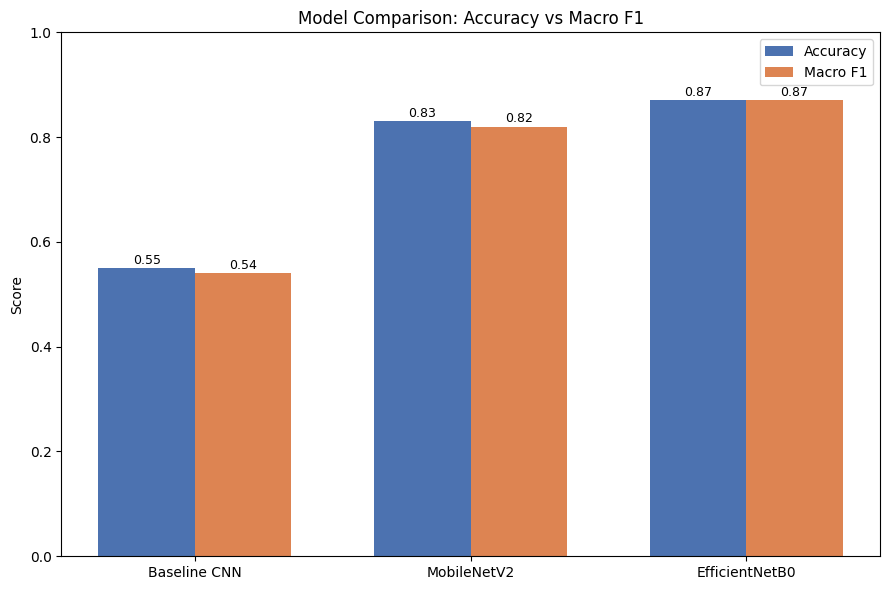

In [3]:
models_list = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models_list]
f1_scores = [results[m]['f1'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(9,6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, f1_scores, width, label='Macro F1', color='#DD8452')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy vs Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylim(0, 1)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x()+bar.get_width()/2, height),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/model_comparison_chart.png', dpi=150)
plt.show()

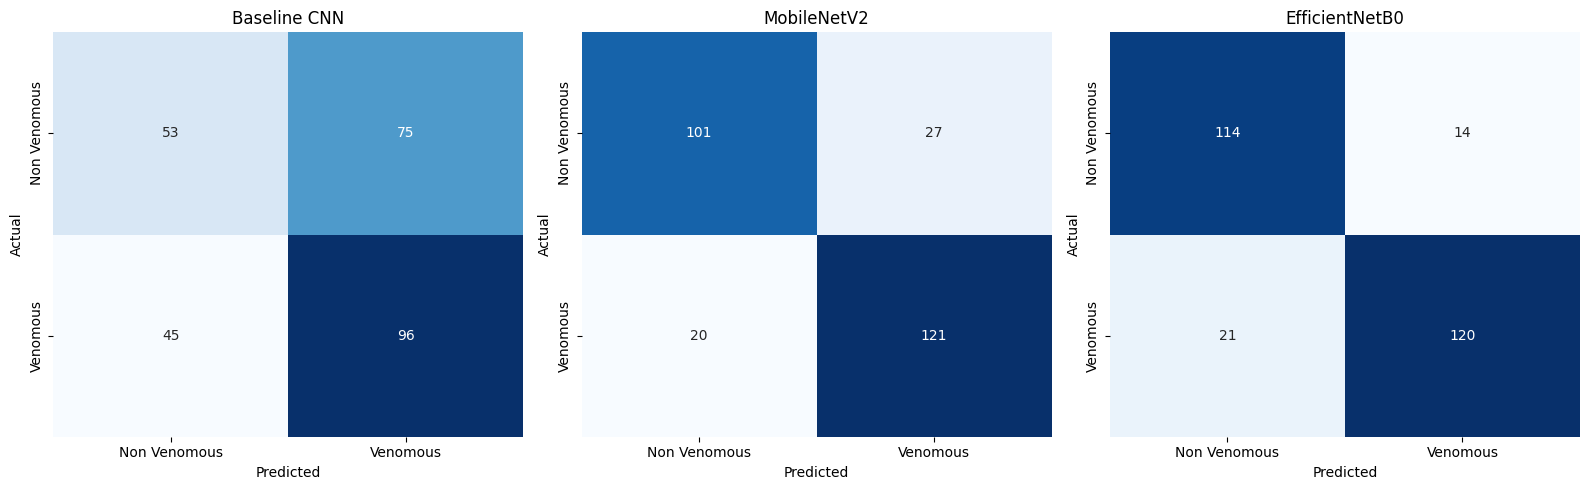

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, (model_name, data) in zip(axes, results.items()):
    sns.heatmap(data['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../notebooks/confusion_matrices_comparison.png', dpi=150)
plt.show()

In [5]:
import pandas as pd

table_data = {
    'Model': models_list,
    'Accuracy': [f"{results[m]['accuracy']:.2f}" for m in models_list],
    'Precision': [f"{results[m]['precision']:.2f}" for m in models_list],
    'Recall': [f"{results[m]['recall']:.2f}" for m in models_list],
    'F1-Score': [f"{results[m]['f1']:.2f}" for m in models_list]
}
df = pd.DataFrame(table_data)
print(df.to_string(index=False))
df.to_csv('../notebooks/model_comparison_table.csv', index=False)
df

         Model Accuracy Precision Recall F1-Score
  Baseline CNN     0.55      0.55   0.55     0.54
   MobileNetV2     0.83      0.83   0.82     0.82
EfficientNetB0     0.87      0.87   0.87     0.87


,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline CNN,0.55,0.55,0.55,0.54
1,MobileNetV2,0.83,0.83,0.82,0.82
2,EfficientNetB0,0.87,0.87,0.87,0.87
